In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
data_dir = '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607'
fn_list = glob.glob(os.path.join(data_dir, 'zbest-*.fits'))

In [4]:
fn_list

['/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-0-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-6-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-5-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-7-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-2-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-3-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-1-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-9-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-4-80607.fits',
 '/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/80607/zbest-8-80607.fits']

In [5]:
zbest = []
for fn in fn_list:
    tmp1 = Table.read(fn, hdu='ZBEST')
    tmp2 = Table.read(fn, hdu='FIBERMAP')
    tmp = join(tmp1, tmp2, keys='TARGETID', metadata_conflicts='silent')
    zbest.append(tmp)
zbest = vstack(zbest)
print(len(zbest))

5000


In [6]:
zbest[:5]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER
int64,float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,bytes3,float32,float32,int16,int32,float64,int32,bytes4,float32,float32,float32,float32,float32,float32,int64,bytes2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,bytes1,int64,int64,int64,int64,int64,int32,int32,bytes8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64
39633314151141374,8.999999999999996e+99,0.0 .. 0.0,-0.0019957014509158224,4.131159871613317e-48,1570,0,STAR,CV,3,1.942668892225729e+84,0,0,0,526,526,365,512,106.2152056363644,54.56440116975422,0.0,0.0,0.0,5400.0,805307138,1,TGT,78.472885,-388.08905,0,3000,0.8822871475992716,3,,0.0,0.0,0.0,0.0,0.0,0.0,0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,,0,0,0,0,0,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,nan,nan,nan,nan,0.0,0.0,0,nan,nan,365,365,1
39633314151142124,25907.49981689453,38.46851494259744 .. -1.8590018889447937,0.8927437244304411,3.17362811111203e-05,0,7751,GALAXY,,10,33.652427673339844,0,0,0,512,512,379,0,106.28134251461526,54.578955548260275,0.0,0.0,0.0,5400.0,35185177428742,1,TGT,68.6526,-384.084,0,3400,0.24149427746867602,3,,0.0,0.0,0.0,0.0,0.0,0.0,0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,,0,0,0,0,0,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,68.604,-384.048,-0.0026428571428571425,-0.0012857142857142863,0.0,0.0,14,0.009051440295807702,0.006106202935189289,379,379,1
39633314155331935,22691.47307792306,487.8033466170296 .. 14.459330342542666,0.3157158809445823,1.9952279789492388e-05,0,7759,GALAXY,,10,11781.74498561956,0,0,0,525,525,398,0,106.30818280511701,54.54835398402204,0.0,0.0,0.0,5400.0,1152921504607895585,1,TGT,64.890884,-392.43365,0,3200,0.8254385737992976,5,,0.0,0.0,0.0,0.0,0.0,0.0,0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,,0,0,0,0,0,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,64.839,-392.396,-0.000785714285714286,-0.004785714285714286,0.0,0.0,14,0.008948263997638234,0.007932753080020291,398,398,1
39633314155332240,24485.55763244629,140.25249828839864 .. 5.092456019936128,0.09171995537810766,8.939309638628971e-07,0,7759,GALAXY,,10,31864.890491485596,0,0,0,511,511,363,0,106.33832175175536,54.58648682512081,0.0,0.0,0.0,5400.0,35185177428742,1,TGT,60.245174,-382.01273,0,3400,0.35233405643198024,3,,0.0,0.0,0.0,0.0,0.0,0.0,0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,,0,0,0,0,0,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,60.201,-381.974,-0.0006428571428571429,-0.0012857142857142859,0.0,0.0,14,0.009910312089651149,0.007406560798180412,363,363,1
39633314155332668,19953.873653113842,106.68605367571158 .. 2.339705213011353,0.8600079334230021,4.3383801725521374e-05,0,7751,GALAXY,,10,1219.6712213382125,0,0,0,494,494,358,0,106.3784301286268,54.619140177608166,0.0,0.0,0.0,5

In [7]:
# Fix the fiberassign data
cat = Table(fitsio.read('/global/cscratch1/sd/rongpu/desi/sv1/deep_coadd/fiberassign-080607.fits.gz'))
cat.sort('TARGETID')
zbest.sort('TARGETID')
print(np.all(cat['TARGETID'] == zbest['TARGETID']))
zbest.remove_columns(np.intersect1d(cat.colnames, zbest.colnames))
zbest = hstack([zbest, cat])

True


In [8]:
zbest[:5]

CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,TARGETID,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL
float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,int64,int16,int32,int32,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64
26192.493725955486,15.08189597101518 .. 4.003519206309445,0.5981887603255207,4.2429394753690026e-05,4,7757,GALAXY,,10,0.09608142077922821,0,0,2,165.246,-373.715,-0.0027857142857142863,0.0005714285714285715,0.0,0.0,14,0.005457628998540876,0.007773581634521595,506,506,1,39633314146945375,1,462,1462,506,0,105.62450343367576,54.61941936477367,0.0,0.0,2020.9487,5400.0,2097217,1,TGT,165.29279,-373.74542,0,3200,0.1330698082934617,1,PSF,0.26581046,0.59905314,2.5593517,673.55853,164.50739,125.60937,0,,0.0,0.0,0.0,0.0,0.0566455,27.478786,59.058567,0.2063931,0.46514508,1.9872524,0.20639311,0.46514514,1.9872525,0,0.0,0.0,0.0,0.0,N,2097217,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0
27107.132614135742,-26.485212532046287 .. 6.995027195517334,1.6280491202653316,3.2235955858983475e-05,0,7758,GALAXY,,10,26.118592262268066,0,0,2,145.509,-378.962,-0.0027142857142857142,-0.0022142857142857133,0.0,0.0,14,0.006568322247184371,0.007620461178395214,522,522,1,39633314146947045,1,440,1440,522,0,105.75893655211898,54.59941167920274,0.0,0.0,2020.9487,5400.0,536871426,1,TGT,145.55751,-378.99387,0,3000,0.9262544191764912,3,PSF,0.23787244,0.24879268,0.3582952,461.05,195.69199,162.98598,0,,0.0,0.0,0.0,0.0,0.05500139,2.9852672,1.3994106,0.18493287,0.19342275,0.278555,0.18493287,0.19342275,0.278555,0,0.0,0.0,0.0,0.0,N,536871426,0,0,3000,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0
31439.492940545082,126.18234785175295 .. -0.2595437870489203,0.753969759288004,5.557674392025168e-05,0,7757,GALAXY,,10,2116.049780189991,0,0,2,135.851,-375.712,-0.002642857142857142,-0.0001428571428571431,0.0,0.0,14,0.006318905872741848,0.0067188434378884845,500,500,1,39633314146947827,1,417,1417,500,0,105.82318098399907,54.61101468580428,0.0,0.0,2020.9487,5400.0,3407977,1,TGT,135.89932,-375.7438,0,3200,0.2171263908781702,1,DEV,0.30449635,1.8070921,9.086302,270.02103,105.312515,58.397743,0,,0.0,0.0,0.0,0.0,0.054167036,28.606735,17.857841,0.1476491,0.8762519,4.405912,0.14764994,0.87625414,4.4059153,0,4.0,0.5513909,0.09726566,-0.09674172,N,3407977,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0
29095.753350809216,4.443904753888243e-05 .. 0.0,2.426769601290306,0.0002138439752009503,0,7758,QSO,,4,1710.4897548407316,0,0,2,128.839,-385.462,-0.004642857142857144,-0.0008571428571428567,0.0,0.0,14,0.007977647343851266,0.00716140449113959,510,510,1,39633314151137496,1,416,1416,510,0,105.87316386688806,54.575047922064655,0.0,0.0,2020.9487,5400.0,8

In [9]:
# SV1 target bits
bitvalues = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 53, 54, 55, 56, 57, 32, 33, 34, 35, 36, 37, 49, 50, 51, 52, 60, 61, 62]
bitnames = ['LRG', 'ELG', 'QSO', 'LRG_OPT', 'LRG_IR', 'LRG_SV_OPT', 'LRG_SV_IR', 'LOWZ_FILLER', 'ELG_SV_GTOT', 'ELG_SV_GFIB', 'ELG_FDR_GTOT', 'ELG_FDR_GFIB', 'QSO_COLOR_4PASS', 'QSO_RF_4PASS', 'QSO_COLOR_8PASS', 'QSO_RF_8PASS', 'QSO_HZ_F', 'QSO_Z5', 'LRG_OPT_NORTH', 'LRG_IR_NORTH', 'LRG_SV_OPT_NORTH', 'LRG_SV_IR_NORTH', 'LOWZ_FILLER_NORTH', 'LRG_OPT_SOUTH', 'LRG_IR_SOUTH', 'LRG_SV_OPT_SOUTH', 'LRG_SV_IR_SOUTH', 'LOWZ_FILLER_SOUTH', 'ELG_SV_GTOT_NORTH', 'ELG_SV_GFIB_NORTH', 'ELG_FDR_GTOT_NORTH', 'ELG_FDR_GFIB_NORTH', 'ELG_SV_GTOT_SOUTH', 'ELG_SV_GFIB_SOUTH', 'ELG_FDR_GTOT_SOUTH', 'ELG_FDR_GFIB_SOUTH', 'QSO_COLOR_4PASS_NORTH', 'QSO_RF_4PASS_NORTH', 'QSO_COLOR_8PASS_NORTH', 'QSO_RF_8PASS_NORTH', 'QSO_HZ_F_NORTH', 'QSO_Z5_NORTH', 'QSO_COLOR_4PASS_SOUTH', 'QSO_RF_4PASS_SOUTH', 'QSO_COLOR_8PASS_SOUTH', 'QSO_RF_8PASS_SOUTH', 'QSO_HZ_F_SOUTH', 'QSO_Z5_SOUTH', 'SKY', 'STD_FAINT', 'STD_WD', 'STD_BRIGHT', 'BAD_SKY', 'SUPP_SKY', 'NO_TARGET', 'BRIGHT_OBJECT', 'IN_BRIGHT_OBJECT', 'NEAR_BRIGHT_OBJECT', 'BGS_ANY', 'MWS_ANY', 'SCND_ANY']

def bitmask_summary(mask_values, names, bits):
    mask_values = np.array(mask_values, dtype=np.uint64)
    t = Table()
    t['name'] = names
    t['bit'] = bits
    t['count'] = 0
    for index in range(len(bits)):
        bit = bits[index]
        t['count'][index] = np.sum(mask_values & (2**bit)>0)
    t['frac (%)'] = t['count']/len(mask_values)*100
    t['frac (%)'].format = "%.3f"
    return t

In [10]:
t = bitmask_summary(zbest['SV1_DESI_TARGET'], bitnames, bitvalues)
t.pprint(max_lines=-1)

         name         bit count frac (%)
--------------------- --- ----- --------
                  LRG   0  1922   38.440
                  ELG   1  1212   24.240
                  QSO   2  1684   33.680
              LRG_OPT   3   530   10.600
               LRG_IR   4   549   10.980
           LRG_SV_OPT   5  1433   28.660
            LRG_SV_IR   6  1640   32.800
          LOWZ_FILLER   7     0    0.000
          ELG_SV_GTOT   8  1042   20.840
          ELG_SV_GFIB   9  1068   21.360
         ELG_FDR_GTOT  10   522   10.440
         ELG_FDR_GFIB  11   540   10.800
      QSO_COLOR_4PASS  12   483    9.660
         QSO_RF_4PASS  13   813   16.260
      QSO_COLOR_8PASS  14   223    4.460
         QSO_RF_8PASS  15   344    6.880
             QSO_HZ_F  16   204    4.080
               QSO_Z5  17   135    2.700
        LRG_OPT_NORTH  18   530   10.600
         LRG_IR_NORTH  19   549   10.980
     LRG_SV_OPT_NORTH  20  1433   28.660
      LRG_SV_IR_NORTH  21  1640   32.800
    LOWZ_FILLER_

In [11]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = zbest['SV1_DESI_TARGET'] & 2**0>0
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

ts_sky = (zbest['DESI_TARGET'] & 2**32>0)
print(np.sum(ts_sky))

530
549
1922

1684
53
6
800


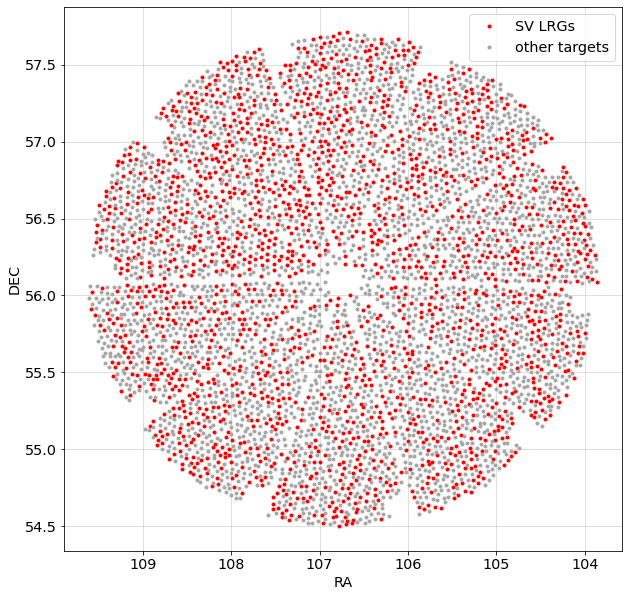

In [12]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [13]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']!=0
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[~mask]

# Remove "no data" fibers
nodata = zbest['ZWARN'] & 2**9>0
print(np.sum(nodata), np.sum(~nodata), np.sum(nodata)/len(nodata))
zbest = zbest[~nodata]

print(len(zbest))

1 4999 0.0002
783 4216 0.15663132626525306
4216


In [14]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

452
469
1640

1421
47
5


In [15]:
mask_zwarn = zbest['ZWARN']==0
print(np.sum((~mask_zwarn) & lrg_opt), np.sum((~mask_zwarn) & lrg_opt)/np.sum(lrg_opt))
print(np.sum((~mask_zwarn) & lrg_ir), np.sum((~mask_zwarn) & lrg_ir)/np.sum(lrg_ir))
print(np.sum((~mask_zwarn) & lrg_sv), np.sum((~mask_zwarn) & lrg_sv)/np.sum(lrg_sv))

1 0.0022123893805309734
3 0.006396588486140725
15 0.009146341463414634


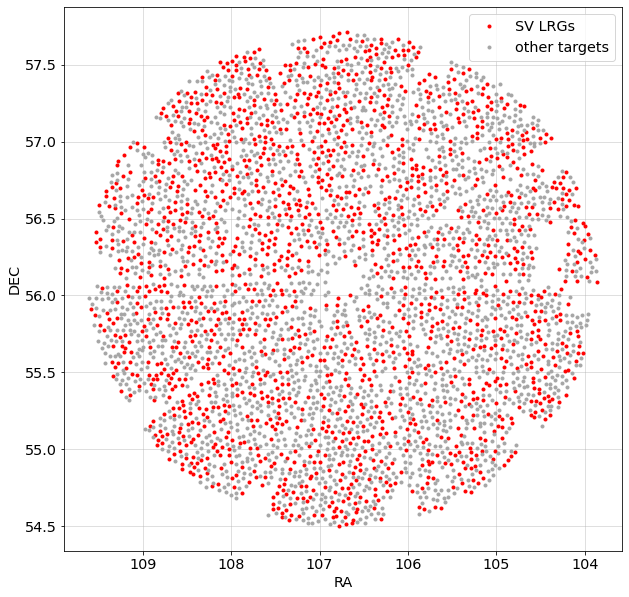

In [16]:
# mask = np.ones(len(zbest), dtype=bool)
plt.figure(figsize=(10, 10))
plt.plot(zbest['TARGET_RA'][lrg_sv], zbest['TARGET_DEC'][lrg_sv], 'r.', ms=6, label='SV LRGs')
plt.plot(zbest['TARGET_RA'][~lrg_sv], zbest['TARGET_DEC'][~lrg_sv], '.', ms=6, label='other targets', color='0.65', alpha=1)
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

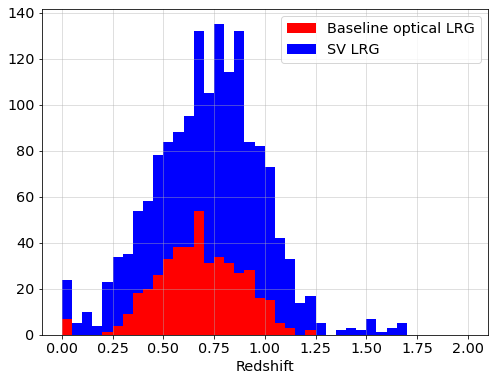

In [17]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

No ZWARN cut:


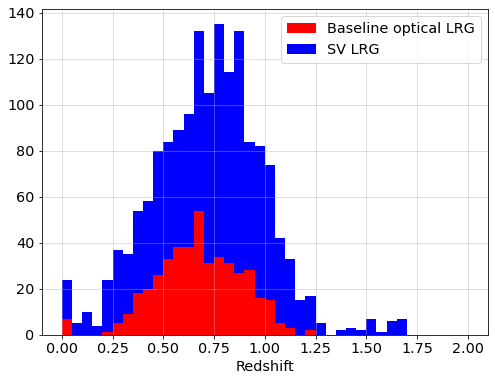

In [18]:
print('No ZWARN cut:')
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.show()

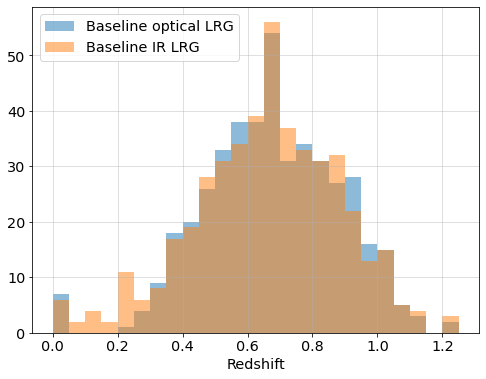

In [19]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline optical LRG'], alpha=0.5)
plt.hist(zbest['Z'][lrg_ir & mask_zwarn], bins=25, range=(0, 1.25), label=['Baseline IR LRG'], alpha=0.5)
plt.xlabel('Redshift')
plt.legend(loc='upper left')
plt.grid(alpha=0.5)
plt.show()

--------
# Stellar contamination

In [43]:
print('LRG_OPT:')
mask = lrg_opt & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_OPT:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,430,95.3
QSO,3,0.7
STAR,18,4.0


In [44]:
print('LRG_IR:')
mask = lrg_ir & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_IR:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,439,94.2
QSO,16,3.4
STAR,11,2.4


In [45]:
print('LRG_SV:')
mask = lrg_sv & mask_zwarn
t = Table()
t['type'], t['counts'] = np.unique(zbest['SPECTYPE'][mask], return_counts=True)
t['frac (%)'] = t['counts']/np.sum(mask)*100
t['frac (%)'].format = '%.1f'
# t.sort('counts')
t

LRG_SV:


type,counts,frac (%)
bytes6,int64,float64
GALAXY,1520,93.5
QSO,41,2.5
STAR,64,3.9


In [23]:
mask_star = zbest['SPECTYPE']=='STAR'
mask_gal = zbest['SPECTYPE']=='GALAXY'
mask_qso = zbest['SPECTYPE']=='QSO'

In [24]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

64
33


In [25]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
mask1 = mask & ((zbest['MASKBITS'] & 2**11>0) | (zbest['MASKBITS'] & 2**8>0))
print(np.sum(mask1))

18
9


In [26]:
mask = lrg_sv & mask_star & mask_zwarn
zbest[mask]

CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,TARGETID,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL
float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,int64,int16,int32,int32,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64
18926.163754677873,-69.4569163611253 .. 0.0,-0.00018922261810775802,2.456111157194734e-05,0,7754,STAR,M,5,210.68508660187217,0,0,2,4.931,-389.075,nan,nan,0.0,0.0,10,nan,nan,491,491,1,39633314159525942,0,489,489,491,0,106.7159346952631,54.5606123348322,0.0,0.0,2020.9487,5400.0,3145825,1,TGT,4.98267,-389.10425,0,3200,0.9242547236231261,1,PSF,0.10767448,0.39614853,2.678509,1071.4373,360.40833,119.54453,0,,0.0,0.0,0.0,0.0,0.057989053,11.080778,3.1591375,0.08379931,0.30830866,2.0845907,0.08379931,0.30830866,2.0845907,0,0.0,0.0,0.0,0.0,N,3145825,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0
21987.018023422876,-55.49975021476179 .. 0.0,-0.0002063553354329123,1.9388136260404992e-05,0,7758,STAR,M,5,275.9254457140778,0,0,2,-1.12,-378.597,-0.0005714285714285717,-0.0027857142857142863,0.0,0.0,14,0.010703804397102395,0.006497252166438187,483,483,1,39633314159526335,0,470,470,483,0,106.75703339076654,54.59914865366423,0.0,0.0,2020.9487,5400.0,2097217,1,TGT,-1.0737727,-378.6346,0,3200,0.7964603661455564,1,PSF,0.058199227,0.4101176,1.9155884,729.0338,268.95044,98.62095,0,,0.0,0.0,0.0,0.0,0.058585014,32.341022,-1.8397659,0.045237537,0.31877932,1.4889631,0.045237537,0.31877932,1.4889631,2816,0.0,0.0,0.0,0.0,N,2097217,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0
23970.364703295196,-85.56857282394634 .. 0.0,-4.224508133754367e-05,1.214919797567311e-05,0,7758,STAR,M,5,1184.5275121057384,0,0,2,-9.377,-373.511,-0.0012857142857142856,0.00014285714285714298,0.0,0.0,14,0.01011364001167306,0.005140872632984738,451,451,1,39633314159526917,0,449,449,451,0,106.81349266557604,54.61804018709363,0.0,0.0,2020.9487,5400.0,3407977,1,TGT,-9.329903,-373.54877,0,3200,0.7780769510031845,1,PSF,0.1154483,0.54892427,3.5854523,718.0813,268.2835,105.74376,0,,0.0,0.0,0.0,0.0,0.059458654,14.150066,1.5690776,0.08992072,0.42754775,2.7926478,0.090254046,0.4285814,2.794724,256,0.0,0.0,0.0,0.0,N,3407977,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0
21148.646779876974,-64.12455354780943 .. 0.0,-0.0001449276152169318,1.6223013952975128e-05,0,7755,STAR,M,5,313.4667511239386,0,0,2,-13.23,-378.75,-1.2390881971262907e-19,-0.0026428571428571425,0.0,0.0,14,0.010295630140987,0.00668153104781061,479,479,1,39633314159527151,0,469,469,479,0,106.83988526466045,54.598793441878016,0.0,0.0,2020.9487,5400.0,3145825,1,TGT,-13.183939,-378.7862,0,3200,0.8849005100695415,1,PSF,0.050128575,0.3702027,2.1698377,735.2522,278.19373,122.20256,0,,0.0

In [27]:
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [28]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2'])
    zbest['gmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_G'])/zbest['FLUX_G']
    zbest['rmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_R'])/zbest['FLUX_R']
    zbest['zmagerr'] = 1/np.sqrt(zbest['FLUX_IVAR_Z'])/zbest['FLUX_Z']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z'])

zbest['z_phot'] = zbest['Z']

433


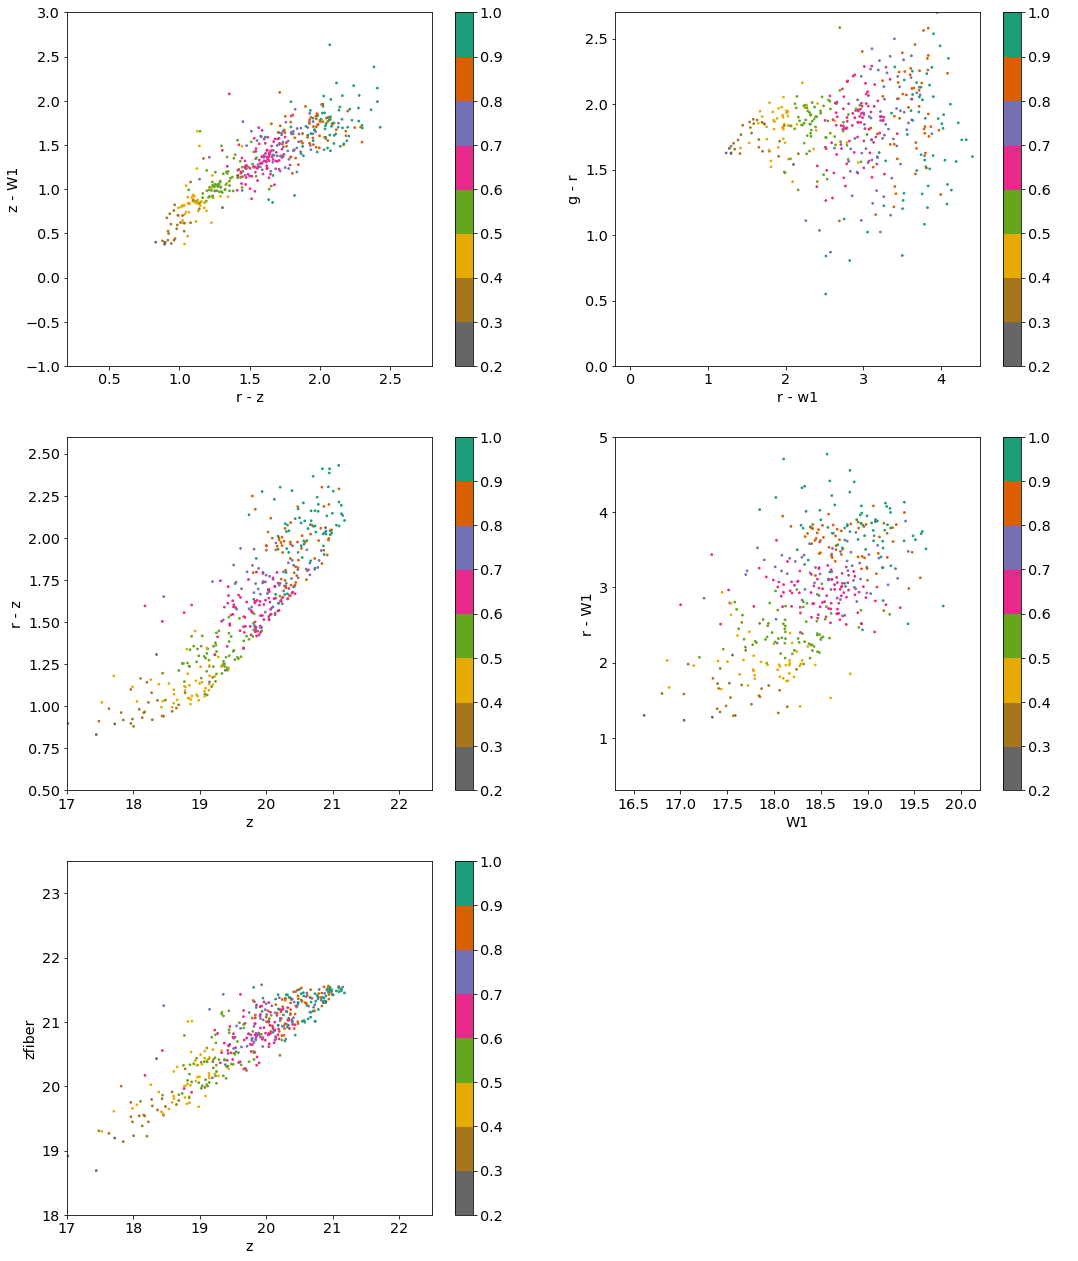

In [29]:
mask = lrg_opt & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

18


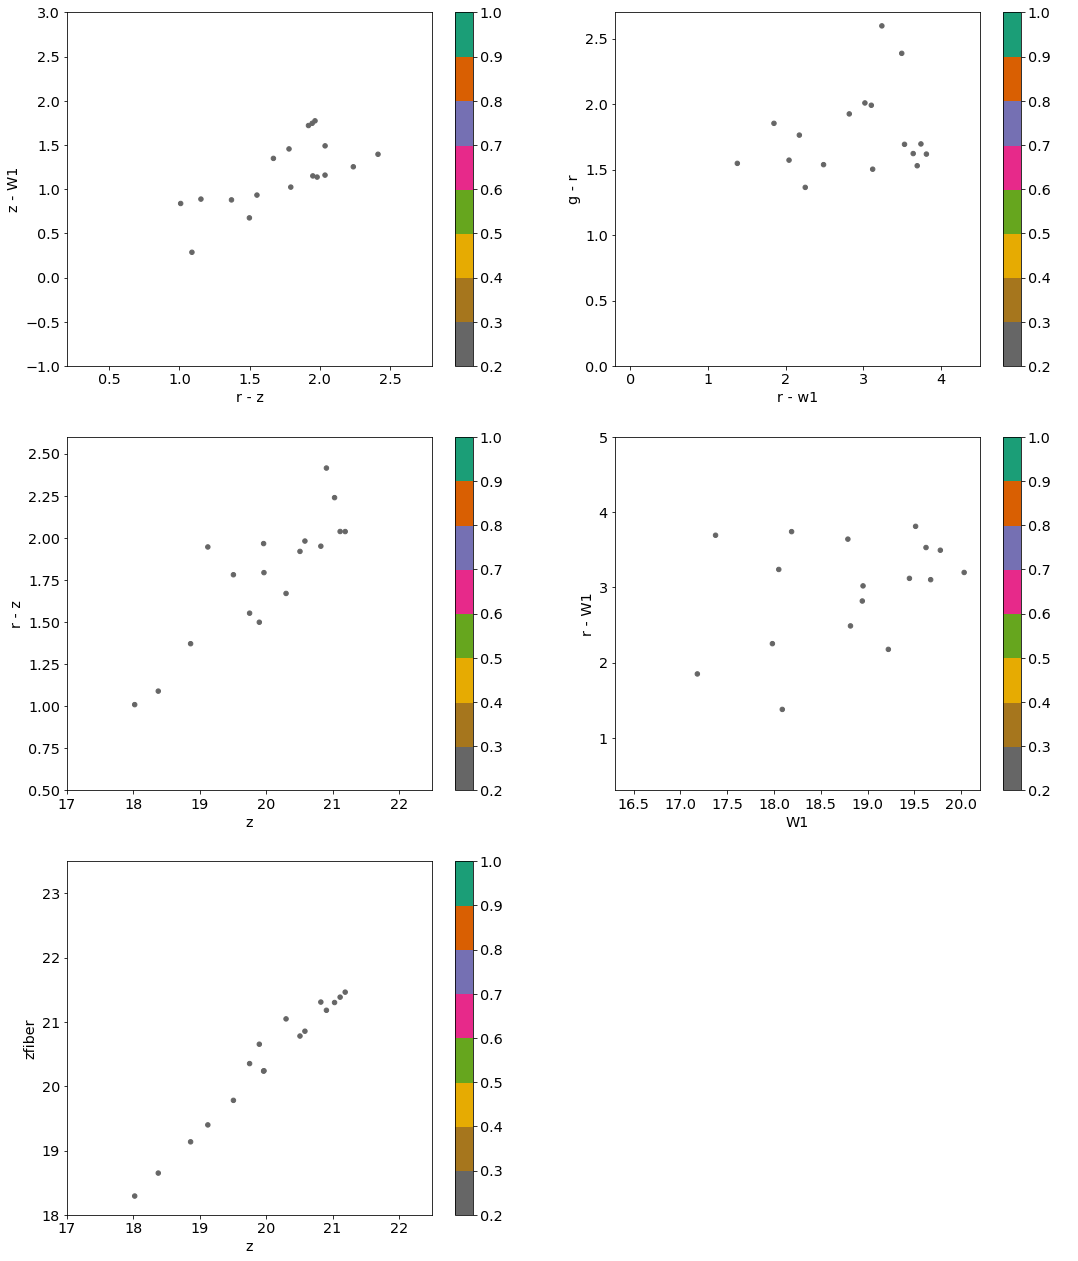

In [30]:
mask = lrg_opt & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

1561


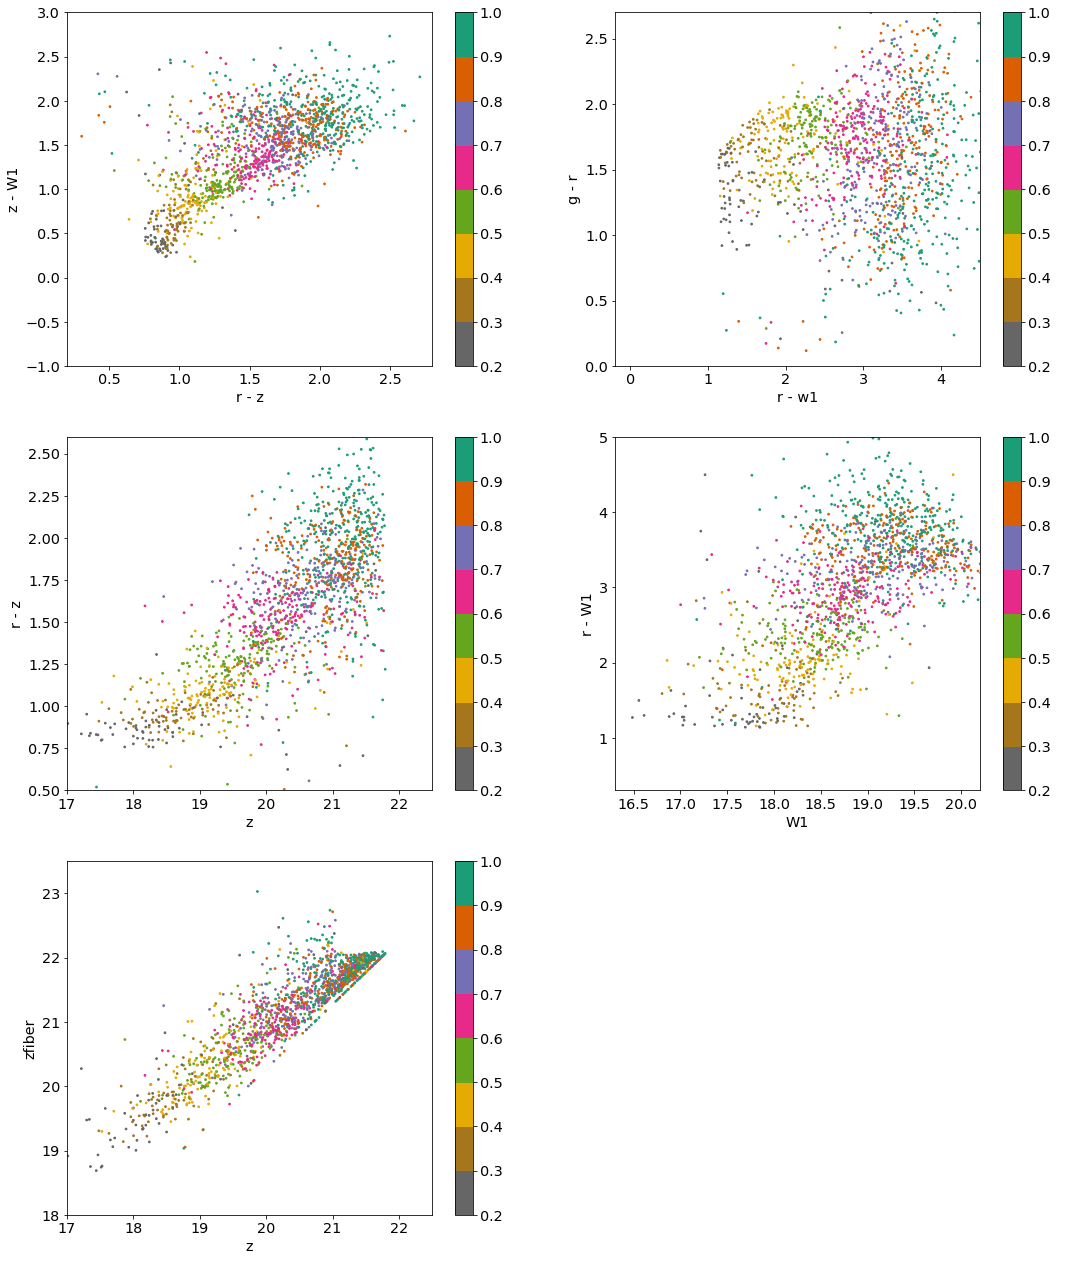

In [31]:
mask = lrg_sv & (~mask_star) & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=3)

64


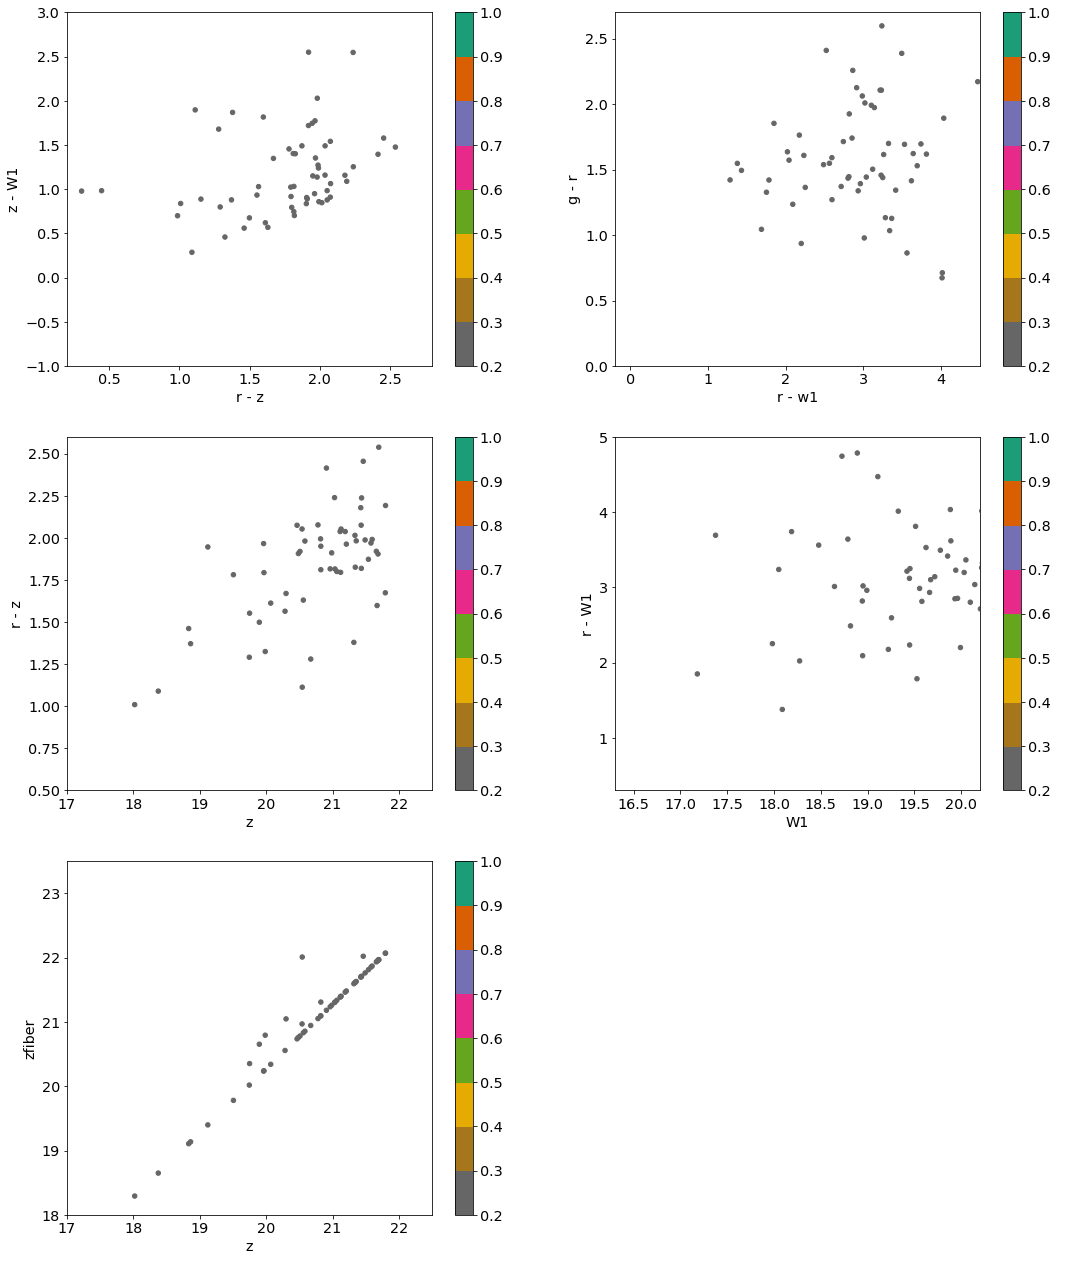

In [32]:
mask = lrg_sv & mask_star & mask_zwarn
print(np.sum(mask))
lrg_plot.color_plot_3x2_new(zbest[mask], ms=20)

In [33]:
mask = lrg_opt & mask_star & mask_zwarn
zbest[mask]

CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,TARGETID,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,int64,int16,int32,int32,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
23970.364703295196,-85.56857282394634 .. 0.0,-4.224508133754367e-05,1.214919797567311e-05,0,7758,STAR,M,5,1184.5275121057384,0,0,2,-9.377,-373.511,-0.0012857142857142856,0.00014285714285714298,0.0,0.0,14,0.01011364001167306,0.005140872632984738,451,451,1,39633314159526917,0,449,449,451,0,106.81349266557604,54.61804018709363,0.0,0.0,2020.9487,5400.0,3407977,1,TGT,-9.329903,-373.54877,0,3200,0.7780769510031845,1,PSF,0.1154483,0.54892427,3.5854523,718.0813,268.2835,105.74376,0,,0.0,0.0,0.0,0.0,0.059458654,14.150066,1.5690776,0.08992072,0.42754775,2.7926478,0.090254046,0.4285814,2.794724,256,0.0,0.0,0.0,0.0,N,3407977,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,24.84403,23.151218,21.11364,19.623104,22.01089,0.3232404,0.11122197,0.027122436,23.422539,21.38496,-4.224508133754367e-05
365835.4216949272,-10519.796778154629 .. 0.0,8.659504690961362e-06,4.0688079807616016e-07,0,7756,STAR,M,5,1031449.6530399991,0,0,2,-97.106,-343.202,0.000571428571428571,-0.0007857142857142856,0.0,0.0,14,0.009149551120917665,0.007333874438911147,330,330,1,39633317678550804,0,333,333,330,0,107.41788383651765,54.73347409695781,0.0,0.0,2020.9487,5400.0,1152921504610779257,1,TGT,-97.07,-343.24744,0,3200,0.4907912221780919,5,PSF,4.4357247,24.444084,61.93811,198.29895,24.555548,0.34424007,0,,0.0,0.0,0.0,0.0,0.066168524,134.10048,74.58173,3.4539852,19.033983,48.229618,23.420105,95.98512,264.4659,144,0.0,0.0,0.0,0.0,N,1152921504610779257,2570,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,20.88259,19.029566,18.020105,17.181423,17.818419,0.016009405,0.008255652,0.02751765,19.301176,18.291716,8.659504690961362e-06
23264.018522664017,-167.32038145577792 .. 0.0,-0.00020463587565588867,8.215971684494055e-06,0,7743,STAR,M,5,3742.371369794899,0,0,2,139.986,-293.068,-0.004714285714285714,-0.0032857142857142863,0.0,0.0,14,0.006979562000174919,0.007874007874011811,673,673,1,39633321155628984,1,297,1297,673,0,105.77269756420134,54.921116330931504,0.0,0.0,2020.9487,5400.0,3932281,1,TGT,140.0201,-293.10272,0,3200,0.9735876177317544,1,PSF,0.23972102,1.0681057,6.256764,970.8539,190.5899,103.88047,0,,0.0,0.0,0.0,0.0,0.052978396,30.514439,0.89137036,0.18675797,0.8321225,4.8744187,0.18677646,0.83220214,4.874871,2816,0.0,0.0,0.0,0.0,N,3932281,0,0,3200,1,0,0,,0,0.

In [34]:
mask = lrg_opt & mask_zwarn
mask &= zbest['MASKBITS'] & 2**8>0
print(np.sum(mask))
zbest[mask]

12


CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,NUM_ITER,FIBER_X,FIBER_Y,MEAN_DELTA_X,MEAN_DELTA_Y,FIBER_RA,FIBER_DEC,COADD_NUMEXP,RMS_DELTA_X,RMS_DELTA_Y,FIRST_FIBER,LAST_FIBER,NUM_FIBER,TARGETID,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,gmag,rmag,zmag,w1mag,w2mag,gmagerr,rmagerr,zmagerr,rfibermag,zfibermag,z_phot
float64,float64,float64,float64,int64,int64,bytes6,bytes20,int64,float64,int32,int32,int64,float64,float64,float64,float64,float64,float64,int16,float64,float64,int64,int64,int64,int64,int16,int32,int32,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64
23970.364703295196,-85.56857282394634 .. 0.0,-4.224508133754367e-05,1.214919797567311e-05,0,7758,STAR,M,5,1184.5275121057384,0,0,2,-9.377,-373.511,-0.0012857142857142856,0.00014285714285714298,0.0,0.0,14,0.01011364001167306,0.005140872632984738,451,451,1,39633314159526917,0,449,449,451,0,106.81349266557604,54.61804018709363,0.0,0.0,2020.9487,5400.0,3407977,1,TGT,-9.329903,-373.54877,0,3200,0.7780769510031845,1,PSF,0.1154483,0.54892427,3.5854523,718.0813,268.2835,105.74376,0,,0.0,0.0,0.0,0.0,0.059458654,14.150066,1.5690776,0.08992072,0.42754775,2.7926478,0.090254046,0.4285814,2.794724,256,0.0,0.0,0.0,0.0,N,3407977,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,24.84403,23.151218,21.11364,19.623104,22.01089,0.3232404,0.11122197,0.027122436,23.422539,21.38496,-4.224508133754367e-05
23264.018522664017,-167.32038145577792 .. 0.0,-0.00020463587565588867,8.215971684494055e-06,0,7743,STAR,M,5,3742.371369794899,0,0,2,139.986,-293.068,-0.004714285714285714,-0.0032857142857142863,0.0,0.0,14,0.006979562000174919,0.007874007874011811,673,673,1,39633321155628984,1,297,1297,673,0,105.77269756420134,54.921116330931504,0.0,0.0,2020.9487,5400.0,3932281,1,TGT,140.0201,-293.10272,0,3200,0.9735876177317544,1,PSF,0.23972102,1.0681057,6.256764,970.8539,190.5899,103.88047,0,,0.0,0.0,0.0,0.0,0.052978396,30.514439,0.89137036,0.18675797,0.8321225,4.8744187,0.18677646,0.83220214,4.874871,2816,0.0,0.0,0.0,0.0,N,3932281,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,24.050735,22.428465,20.509125,18.788736,22.624855,0.13388039,0.06781657,0.015681345,22.699532,20.780193,-0.00020463587565588867
27400.944531630998,-269.98239920364966 .. 0.0,-0.00011480688905527951,4.56460088464316e-06,0,7751,STAR,M,5,9912.475329566474,0,0,2,202.818,-196.86,-0.0019999999999999996,-0.0034285714285714293,0.0,0.0,14,0.008298020417975775,0.009870591240071256,751,751,1,39633324628508879,1,271,1271,751,0,105.31004456846108,55.295376993226554,0.0,0.0,2020.9487,5400.0,3932281,1,TGT,202.83849,-196.90224,0,3200,0.5956699717816187,1,PSF,0.35549933,1.6949488,10.36286,988.1127,428.9111,67.06831,0,,0.0,0.0,0.0,0.0,0.052369434,53.074898,6.2869935,0.27635318,1.317596,8.0557375,0.2763808,1.317704,8.056093,2816,0.0,0.0,0.0,0.0,N,3932281,0,0,3200,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,

----------
# Delta-chi-square

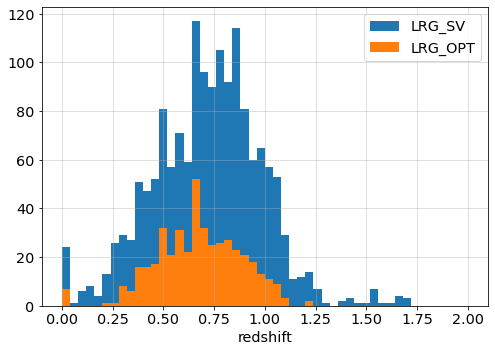

In [35]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['Z'][lrg_sv & mask_zwarn],  50, range=(0, 2.), label='LRG_SV')
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], 50, range=(0, 2.), label='LRG_OPT')
plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

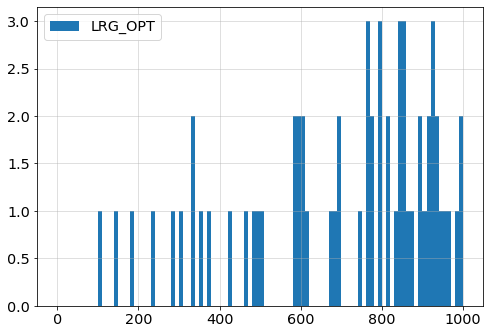

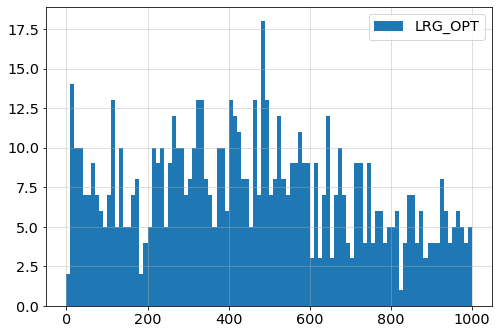

In [36]:
plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_opt & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5.5))
plt.hist(zbest['DELTACHI2'][lrg_sv & mask_zwarn], 100, range=(0, 1000.), label='LRG_OPT')
# plt.xlabel('redshift')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

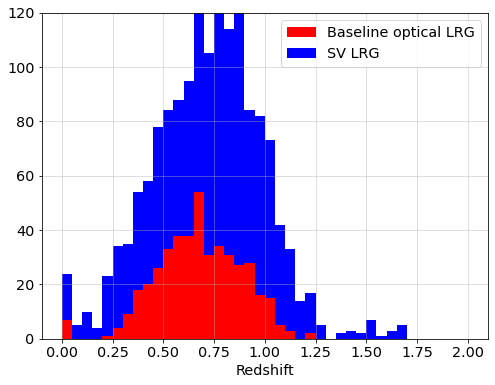

In [37]:
plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)
plt.show()

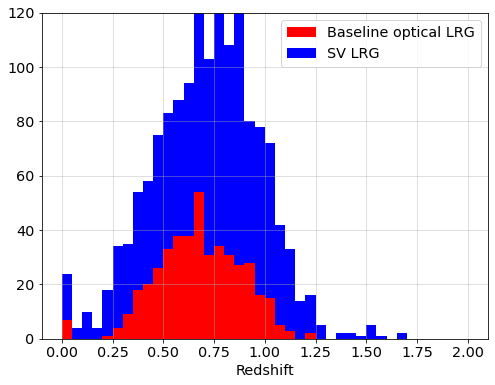

In [38]:
mask_dchi2 = zbest['DELTACHI2']>50

plt.figure(figsize=(8, 6))
plt.hist(zbest['Z'][lrg_opt & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='red', label=['Baseline optical LRG'], zorder=1)
plt.hist(zbest['Z'][lrg_sv & mask_zwarn & mask_dchi2], bins=40, range=(0, 2.0), color='blue', label=['SV LRG'], zorder=0)
plt.xlabel('Redshift')
plt.legend(loc='upper right')
plt.grid(alpha=0.5)
plt.ylim(0, 120)

plt.show()

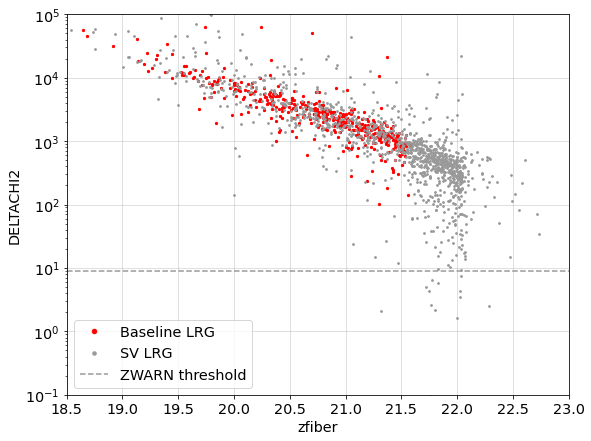

In [39]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

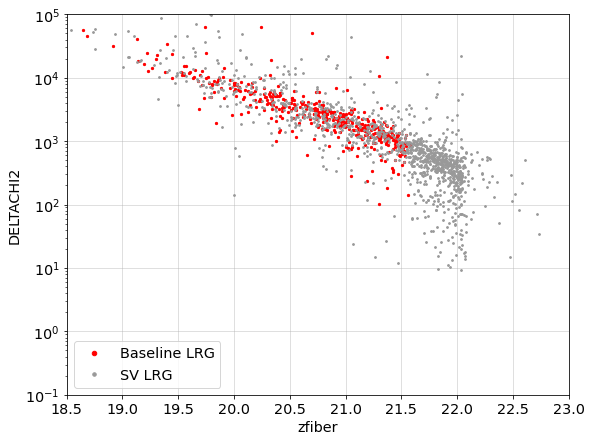

In [40]:
# Add ZWARN cut
plt.figure(figsize=(9, 7))
plt.plot(zbest['zfibermag'][lrg_opt & mask_zwarn], zbest['DELTACHI2'][lrg_opt & mask_zwarn], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['zfibermag'][(~lrg_opt) & lrg_sv & mask_zwarn], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv & mask_zwarn], 'b.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('DELTACHI2')
plt.axis([18.5, 23., .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

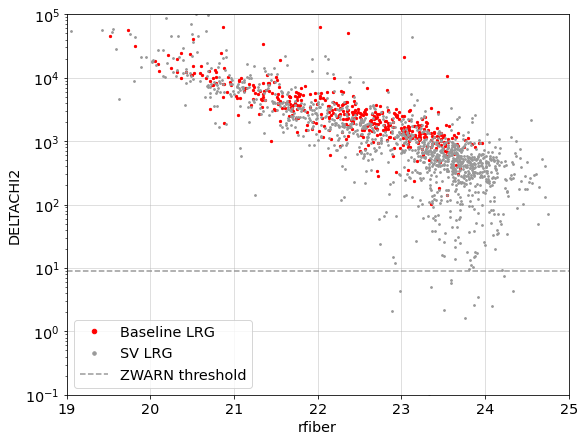

In [41]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['rfibermag'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['rfibermag'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.axhline(9., ls='--', color='0.6', label='ZWARN threshold')
plt.yscale('log')
plt.xlabel('rfiber')
plt.ylabel('DELTACHI2')
plt.axis([19, 25, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()

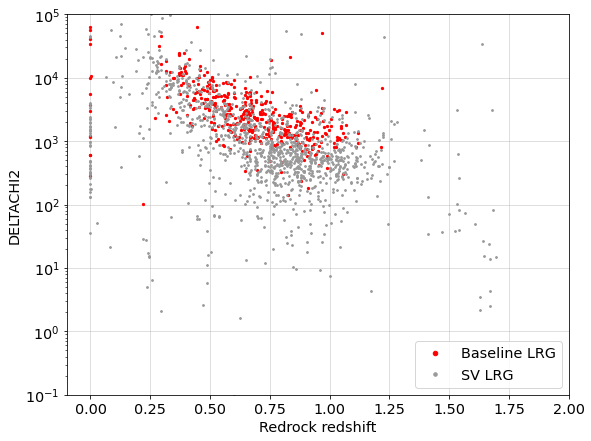

In [42]:
plt.figure(figsize=(9, 7))
plt.plot(zbest['Z'][lrg_opt], zbest['DELTACHI2'][lrg_opt], 'r.', ms=4.5, alpha=1, label='Baseline LRG')
plt.plot(zbest['Z'][(~lrg_opt) & lrg_sv], zbest['DELTACHI2'][(~lrg_opt) & lrg_sv], '.', color='0.6', ms=3.5, alpha=1, label='SV LRG')
plt.yscale('log')
plt.xlabel('Redrock redshift')
plt.ylabel('DELTACHI2')
plt.axis([-0.1, 2, .1, 100000])
plt.legend(markerscale=2)
plt.grid(alpha=0.5)
plt.show()